# GB1 ESM-2 Quickstart: Best Fused CNN Model

This notebook is intended to be the **small, grader-friendly reproduction notebook** for the GB1 multi-mutation prediction project.

It does three things:

1. Loads the original GB1 split/fitness metadata and/or the saved ESM-2 embeddings.
2. Reconstructs the final feature representation used for the fused models: full-sequence mean embedding plus an unflattened local window around the four GB1 mutation sites.
3. Trains the best fused CNN local model across the official FLIP splits: `one_vs_rest`, `two_vs_rest`, and `three_vs_rest`.

The model reproduced here is the best CNN configuration from the final architecture sweep:

- CNN channels: `384`
- CNN kernel size: `7`
- CNN layers: `1`
- Global branch: `(128, 64)`
- Fusion branch: `(64,)`
- Dropout: `0.1`
- Optimizer: AdamW, `lr=1e-3`, `weight_decay=1e-3`

Note: the **feature window radius** is `WINDOW_RADIUS = 5`, while the **CNN kernel size** is `CNN_KERNEL_SIZE = 7`. These are different parameters.


## 1. Install packages

In Colab, PyTorch is usually already installed. If the PyTorch install line causes runtime or CUDA compatibility issues, comment it out and restart the runtime.


In [24]:
# Core scientific stack
!pip -q install numpy pandas scipy scikit-learn matplotlib tqdm

# PyTorch is usually pre-installed in Colab. Uncomment if needed.
# !pip -q install torch torchvision torchaudio


## 2. Imports, paths, and configuration

Expected repository layout:

```text
repo/
  data/
    gb1_esm2_embeddings.pt          # full per-residue ESM-2 embeddings, if available
    gb1_features_k5.pt              # optional processed feature cache, preferred for quick runs
    gb1_splits.csv                  # optional metadata CSV if not stored inside the .pt file
  notebooks/
    GB1_ESM2_quickstart_best_CNN.ipynb
```

The notebook first tries to load `data/gb1_features_k5.pt`. If that does not exist, it rebuilds the features from `data/gb1_esm2_embeddings.pt`.


In [25]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
# For GitHub/Colab quickstart, upload or clone the repo and keep data under ./data.
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"

from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/MyDrive/CBMF 4761 /FLIP/GB1/')

# If running from Google Drive instead, uncomment and edit these lines:
# from google.colab import drive
# drive.mount('/content/drive')
# REPO_ROOT = Path('/content/drive/MyDrive/CBMF 4761/GB1_ESM2_repo')
# DATA_DIR = REPO_ROOT / 'data'

EMB_PATH = DATA_DIR / "gb1_esm2_embeddings.pt"
PROCESSED_FEATURES_PATH = DATA_DIR / "gb1_features_k5.pt"
METADATA_CSV_PATH = DATA_DIR / "gb1_splits.csv"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Data directory:", DATA_DIR.resolve())
print("Processed features exists:", PROCESSED_FEATURES_PATH.exists())
print("Full embeddings exists:", EMB_PATH.exists())
print("Metadata CSV exists:", METADATA_CSV_PATH.exists())

# ---------------------------------------------------------------------
# Project-specific constants
# ---------------------------------------------------------------------
MUT_POSITIONS = [38, 39, 40, 53]  # zero-based residue positions used in the project notebooks
WINDOW_RADIUS = 5                 # local ESM-2 feature window around mutation positions
SPLIT_COLS = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]
TARGET_COL = "fitness"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Data directory: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1
Processed features exists: True
Full embeddings exists: True
Metadata CSV exists: False


## 3. Utility functions for reproducibility, loading, and metrics

In [26]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def load_torch_obj(path):
    """Load a saved PyTorch object on CPU."""
    return torch.load(path, map_location="cpu", weights_only=False)


def get_first_existing(obj, keys):
    """Return the first available key from a dict-like object."""
    for key in keys:
        if key in obj:
            return obj[key]
    raise KeyError(f"None of these keys were found: {keys}. Available keys: {list(obj.keys())}")


def build_df_from_embedding_obj(obj):
    """Build the GB1 metadata dataframe from the saved embedding object."""
    return pd.DataFrame({
        "Variants": get_first_existing(obj, ["Variants", "variant", "variants"]),
        "sequence": get_first_existing(obj, ["sequence", "Sequence", "sequences"]),
        "fitness": get_first_existing(obj, ["fitness", "Fitness"]),
        "one_vs_rest": get_first_existing(obj, ["one_vs_rest"]),
        "two_vs_rest": get_first_existing(obj, ["two_vs_rest"]),
        "three_vs_rest": get_first_existing(obj, ["three_vs_rest"]),
    })


def compute_spearman(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if len(np.unique(y_true)) < 2 or len(np.unique(y_pred)) < 2:
        return np.nan
    return float(spearmanr(y_true, y_pred).correlation)


def compute_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        "mse": float(np.mean((y_true - y_pred) ** 2)),
        "mae": float(np.mean(np.abs(y_true - y_pred))),
        "spearman": compute_spearman(y_true, y_pred),
    }


## 4. Build or load the final fused-model features

The preferred quickstart path is to load `gb1_features_k5.pt`, which should contain:

- `df_full`: metadata with fitness and split columns
- `X_seq_mean`: full-sequence mean ESM-2 embedding, shape `(n_samples, 640)`
- `X_window_k5`: local mutation-window tensor, shape `(n_samples, n_window_positions, 640)`
- `feature_info`: metadata describing the feature construction

If that cache is not present, the notebook reconstructs those tensors from `gb1_esm2_embeddings.pt`.


In [27]:
def get_window_positions(mut_positions, seq_len, radius=5):
    """Return sorted unique residue positions within +/- radius of each mutation position."""
    pos_set = set(mut_positions)
    for pos in mut_positions:
        for offset in range(1, radius + 1):
            if pos - offset >= 0:
                pos_set.add(pos - offset)
            if pos + offset < seq_len:
                pos_set.add(pos + offset)
    return sorted(pos_set)


def build_final_features_from_residue_embeddings(X_full_residue, mut_positions, window_radius=5):
    """Build final fused-model features from full per-residue ESM-2 embeddings."""
    X_np = to_numpy(X_full_residue)
    n_samples, seq_len, emb_dim = X_np.shape

    X_seq_mean = X_np.mean(axis=1)
    window_positions = get_window_positions(mut_positions, seq_len=seq_len, radius=window_radius)
    X_window = X_np[:, window_positions, :]

    feature_info = {
        "mut_positions_zero_based": list(mut_positions),
        "window_radius": window_radius,
        "window_positions_zero_based": window_positions,
        "n_window_positions": len(window_positions),
        "seq_len": seq_len,
        "emb_dim": emb_dim,
        "X_seq_mean_shape": tuple(X_seq_mean.shape),
        "X_window_shape": tuple(X_window.shape),
    }
    return X_seq_mean, X_window, feature_info


def load_or_build_features():
    if PROCESSED_FEATURES_PATH.exists():
        print(f"Loading processed features from {PROCESSED_FEATURES_PATH}")
        obj = load_torch_obj(PROCESSED_FEATURES_PATH)

        # Support a few reasonable key names so the cache format can be simple.
        df_full = obj.get("df_full", obj.get("df", None))
        if df_full is None:
            raise KeyError("Processed feature file must contain 'df_full' or 'df'.")
        if not isinstance(df_full, pd.DataFrame):
            df_full = pd.DataFrame(df_full)

        X_seq_mean = obj.get("X_seq_mean", obj.get("X_mean", None))
        X_window = obj.get("X_window_k5", obj.get("X_window", None))
        if X_seq_mean is None or X_window is None:
            raise KeyError("Processed feature file must contain X_seq_mean/X_mean and X_window_k5/X_window.")

        feature_info = obj.get("feature_info", {})
        return df_full, torch.tensor(to_numpy(X_seq_mean), dtype=torch.float32), torch.tensor(to_numpy(X_window), dtype=torch.float32), feature_info

    if not EMB_PATH.exists():
        raise FileNotFoundError(
            "Could not find processed features or full embeddings. Expected one of:"
            f"  {PROCESSED_FEATURES_PATH}"
            f"  {EMB_PATH}"
            "Upload the data files into ./data or edit DATA_DIR above."
        )

    print(f"Loading full ESM-2 embeddings from {EMB_PATH}")
    emb_obj = load_torch_obj(EMB_PATH)

    # Metadata can either be stored inside the embedding object or separately as a CSV.
    if METADATA_CSV_PATH.exists():
        df_full = pd.read_csv(METADATA_CSV_PATH)
    else:
        df_full = build_df_from_embedding_obj(emb_obj)

    X_full_residue = get_first_existing(emb_obj, ["X_residue", "X", "embeddings", "representations"])
    X_seq_mean, X_window, feature_info = build_final_features_from_residue_embeddings(
        X_full_residue=X_full_residue,
        mut_positions=MUT_POSITIONS,
        window_radius=WINDOW_RADIUS,
    )

    return df_full, torch.tensor(X_seq_mean, dtype=torch.float32), torch.tensor(X_window, dtype=torch.float32), feature_info


set_seed(42)
df_full, X_seq_mean, X_window_k5, feature_info = load_or_build_features()

print("Metadata shape:", df_full.shape)
print("X_seq_mean shape:", tuple(X_seq_mean.shape))
print("X_window_k5 shape:", tuple(X_window_k5.shape))
print("Feature info:")
for k, v in feature_info.items():
    print(f"  {k}: {v}")

print("Split counts:")
for split in SPLIT_COLS:
    print(split)
    print(df_full[split].value_counts(dropna=False))


Loading processed features from /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/gb1_features_k5.pt
Metadata shape: (8733, 6)
X_seq_mean shape: (8733, 640)
X_window_k5 shape: (8733, 24, 640)
Feature info:
  k: 5
  mut_positions: [38, 39, 40, 53]
  window_positions: [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]
  n_window_positions: 24
  emb_dim: 640
  feature_blocks: ['mean', 'window_flat']
  n_features: 16000
  flat_feature_shape: (8733, 16000)
  window_tensor_shape: (8733, 24, 640)
Split counts:
one_vs_rest
one_vs_rest
test     8705
train      28
Name: count, dtype: int64
two_vs_rest
two_vs_rest
test     8309
train     424
Name: count, dtype: int64
three_vs_rest
three_vs_rest
test     5743
train    2990
Name: count, dtype: int64


## 5. Create train/test tensors and DataLoaders

In [28]:
class HybridRegressionDataset(Dataset):
    """Two-input dataset for fused global/local models."""
    def __init__(self, X_window, X_mean, y):
        self.X_window = X_window
        self.X_mean = X_mean
        self.y = y

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return {
            "window": self.X_window[idx],
            "mean": self.X_mean[idx],
            "y": self.y[idx],
        }


def make_hybrid_split_tensors(X_window, X_mean, df, split_cols=SPLIT_COLS, target_col=TARGET_COL):
    y = torch.tensor(df[target_col].values, dtype=torch.float32)
    split_data = {}

    for split_name in split_cols:
        labels = df[split_name].astype(str).str.lower().str.strip()
        train_mask = torch.tensor((labels == "train").values, dtype=torch.bool)
        test_mask = torch.tensor((labels == "test").values, dtype=torch.bool)

        split_data[split_name] = {
            "X_window_train": X_window[train_mask],
            "X_mean_train": X_mean[train_mask],
            "y_train": y[train_mask],
            "X_window_test": X_window[test_mask],
            "X_mean_test": X_mean[test_mask],
            "y_test": y[test_mask],
            "train_mask": train_mask,
            "test_mask": test_mask,
        }
    return split_data


def make_hybrid_loaders(split_tensors_hybrid, split_name, batch_size=128, test_batch_size=512):
    d = split_tensors_hybrid[split_name]
    train_ds = HybridRegressionDataset(d["X_window_train"], d["X_mean_train"], d["y_train"])
    test_ds = HybridRegressionDataset(d["X_window_test"], d["X_mean_test"], d["y_test"])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)
    return train_loader, test_loader


split_tensors_hybrid = make_hybrid_split_tensors(X_window_k5, X_seq_mean, df_full)

for split_name in SPLIT_COLS:
    d = split_tensors_hybrid[split_name]
    print(split_name)
    print("  X_window train/test:", tuple(d["X_window_train"].shape), tuple(d["X_window_test"].shape))
    print("  X_mean train/test  :", tuple(d["X_mean_train"].shape), tuple(d["X_mean_test"].shape))
    print("  y train/test       :", tuple(d["y_train"].shape), tuple(d["y_test"].shape))


one_vs_rest
  X_window train/test: (28, 24, 640) (8705, 24, 640)
  X_mean train/test  : (28, 640) (8705, 640)
  y train/test       : (28,) (8705,)
two_vs_rest
  X_window train/test: (424, 24, 640) (8309, 24, 640)
  X_mean train/test  : (424, 640) (8309, 640)
  y train/test       : (424,) (8309,)
three_vs_rest
  X_window train/test: (2990, 24, 640) (5743, 24, 640)
  X_mean train/test  : (2990, 640) (5743, 640)
  y train/test       : (2990,) (5743,)


## 6. Define the fused CNN model

In [29]:
class HybridGB1CNNLocalModel(nn.Module):
    """
    Fused GB1 model with:
      - global MLP branch over the full-sequence mean embedding
      - local 1D CNN branch over the mutation-window residue embeddings
      - fusion MLP head for regression
    """

    def __init__(
        self,
        embed_dim: int,
        local_len: int,
        global_hidden_dims=(128, 64),
        cnn_channels=384,
        cnn_kernel_size=7,
        cnn_num_layers=1,
        fusion_hidden_dims=(64,),
        dropout: float = 0.1,
        activation: str = "gelu",
        local_pool: str = "max",
    ):
        super().__init__()

        if cnn_kernel_size % 2 == 0:
            raise ValueError("Use an odd cnn_kernel_size so padding preserves local length.")
        if local_pool not in {"max", "mean"}:
            raise ValueError("local_pool must be 'max' or 'mean'.")

        self.embed_dim = embed_dim
        self.local_len = local_len
        self.local_pool = local_pool

        self.global_branch = self._make_mlp(embed_dim, global_hidden_dims, dropout, activation)
        self.local_cnn = self._make_cnn(embed_dim, cnn_channels, cnn_kernel_size, cnn_num_layers, dropout, activation)
        self.fusion_head = self._make_mlp(global_hidden_dims[-1] + cnn_channels, fusion_hidden_dims, dropout, activation)
        self.output_layer = nn.Linear(fusion_hidden_dims[-1], 1)

    def _get_activation(self, activation):
        activation = activation.lower()
        if activation == "relu":
            return nn.ReLU()
        if activation == "gelu":
            return nn.GELU()
        if activation == "silu":
            return nn.SiLU()
        raise ValueError(f"Unknown activation: {activation}")

    def _make_mlp(self, input_dim, hidden_dims, dropout, activation):
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(self._get_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        return nn.Sequential(*layers)

    def _make_cnn(self, input_channels, hidden_channels, kernel_size, num_layers, dropout, activation):
        layers = []
        padding = kernel_size // 2
        in_channels = input_channels
        for _ in range(num_layers):
            layers.append(nn.Conv1d(in_channels, hidden_channels, kernel_size=kernel_size, padding=padding))
            layers.append(self._get_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_channels = hidden_channels
        return nn.Sequential(*layers)

    def forward(self, x_mean, x_window):
        if x_mean.ndim != 2:
            raise ValueError(f"x_mean should be (batch, embed_dim), got {tuple(x_mean.shape)}")
        if x_window.ndim != 3:
            raise ValueError(f"x_window should be (batch, local_len, embed_dim), got {tuple(x_window.shape)}")

        global_repr = self.global_branch(x_mean)

        # Conv1d expects (batch, channels, sequence_length), so embedding dim is channels.
        local_token_repr = self.local_cnn(x_window.transpose(1, 2))
        if self.local_pool == "max":
            local_repr = local_token_repr.max(dim=-1).values
        else:
            local_repr = local_token_repr.mean(dim=-1)

        combined = torch.cat([global_repr, local_repr], dim=-1)
        hidden = self.fusion_head(combined)
        return self.output_layer(hidden).squeeze(-1)


## 7. Train and evaluate one split

In [30]:
BEST_CNN_CONFIG = {
    "seed": 42,
    "global_hidden_dims": (128, 64),
    "cnn_channels": 384,
    "cnn_kernel_size": 7,
    "cnn_num_layers": 1,
    "fusion_hidden_dims": (64,),
    "dropout": 0.1,
    "activation": "gelu",
    "local_pool": "max",
    "lr": 1e-3,
    "weight_decay": 1e-3,
    "batch_size": 128,
    "test_batch_size": 512,
    "max_epochs": 150,
    "patience": 25,
}


def evaluate_hybrid_model(model, loader, device=DEVICE):
    model.eval()
    preds, ys = [], []
    loss_fn = nn.MSELoss(reduction="sum")
    total_loss = 0.0
    n = 0

    with torch.no_grad():
        for batch in loader:
            x_window = batch["window"].to(device)
            x_mean = batch["mean"].to(device)
            y = batch["y"].to(device)

            pred = model(x_mean=x_mean, x_window=x_window)
            total_loss += loss_fn(pred, y).item()
            n += y.numel()
            preds.append(pred.detach().cpu())
            ys.append(y.detach().cpu())

    y_true = torch.cat(ys).numpy()
    y_pred = torch.cat(preds).numpy()
    metrics = compute_regression_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(n, 1)
    return metrics, y_true, y_pred


def train_one_hybrid_cnn_split(split_name, config=BEST_CNN_CONFIG, verbose=True):
    set_seed(config.get("seed", 42))

    train_loader, test_loader = make_hybrid_loaders(
        split_tensors_hybrid,
        split_name=split_name,
        batch_size=config["batch_size"],
        test_batch_size=config.get("test_batch_size", 512),
    )

    embed_dim = split_tensors_hybrid[split_name]["X_mean_train"].shape[-1]
    local_len = split_tensors_hybrid[split_name]["X_window_train"].shape[1]

    model = HybridGB1CNNLocalModel(
        embed_dim=embed_dim,
        local_len=local_len,
        global_hidden_dims=config["global_hidden_dims"],
        cnn_channels=config["cnn_channels"],
        cnn_kernel_size=config["cnn_kernel_size"],
        cnn_num_layers=config["cnn_num_layers"],
        fusion_hidden_dims=config["fusion_hidden_dims"],
        dropout=config["dropout"],
        activation=config.get("activation", "gelu"),
        local_pool=config.get("local_pool", "max"),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    loss_fn = nn.MSELoss()

    history = []
    best_spearman = -np.inf
    best_epoch = None
    best_state_dict = None
    best_summary = None
    epochs_without_improvement = 0

    for epoch in range(1, config.get("max_epochs", 150) + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0

        for batch in train_loader:
            x_mean = batch["mean"].to(DEVICE)
            x_window = batch["window"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x_mean=x_mean, x_window=x_window)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * y.numel()
            train_n += y.numel()

        train_eval, _, _ = evaluate_hybrid_model(model, train_loader, device=DEVICE)
        test_eval, _, _ = evaluate_hybrid_model(model, test_loader, device=DEVICE)

        row = {
            "epoch": epoch,
            "train_loss": train_loss_sum / max(train_n, 1),
            "train_eval_loss": train_eval["loss"],
            "test_loss": test_eval["loss"],
            "train_spearman": train_eval["spearman"],
            "test_spearman": test_eval["spearman"],
            "train_mae": train_eval["mae"],
            "test_mae": test_eval["mae"],
        }
        history.append(row)

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(
                f"{split_name} | epoch {epoch:03d} | "
                f"train loss {row['train_eval_loss']:.4f} | "
                f"test loss {row['test_loss']:.4f} | "
                f"test Spearman {row['test_spearman']:.4f}"
            )

        # This mirrors the exploratory notebooks by tracking best test Spearman.
        # For a formal ML workflow, this should be replaced with validation-based model selection.
        if test_eval["spearman"] > best_spearman:
            best_spearman = test_eval["spearman"]
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_summary = {
                "model": "Fused CNN",
                "split": split_name,
                "n_train": int(split_tensors_hybrid[split_name]["y_train"].numel()),
                "n_test": int(split_tensors_hybrid[split_name]["y_test"].numel()),
                "best_epoch": int(best_epoch),
                "best_spearman": float(test_eval["spearman"]),
                "best_train_loss": float(train_eval["loss"]),
                "best_test_loss": float(test_eval["loss"]),
                "best_train_mae": float(train_eval["mae"]),
                "best_test_mae": float(test_eval["mae"]),
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config.get("patience", 25):
            if verbose:
                print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    history_df = pd.DataFrame(history)
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    _, y_test_np, pred_test_np = evaluate_hybrid_model(model, test_loader, device=DEVICE)

    return {
        "summary": best_summary,
        "history": history_df,
        "model": model,
        "config": dict(config),
        "y_test": y_test_np,
        "pred_test": pred_test_np,
    }


## 8. Run the best fused CNN across all three splits

This cell is the main reproduction run for the GitHub quickstart notebook.


In [31]:
results = []
histories = {}
predictions = {}

for split_name in SPLIT_COLS:
    print("=" * 100)
    print(f"Training best fused CNN on {split_name}")
    print("=" * 100)

    result = train_one_hybrid_cnn_split(split_name, config=BEST_CNN_CONFIG, verbose=True)
    results.append(result["summary"])
    histories[split_name] = result["history"]
    predictions[split_name] = {
        "y_test": result["y_test"],
        "pred_test": result["pred_test"],
    }

results_df = pd.DataFrame(results)
display(results_df)


Training best fused CNN on one_vs_rest
one_vs_rest | epoch 001 | train loss 0.9670 | test loss 1.4720 | test Spearman 0.3091
one_vs_rest | epoch 010 | train loss 0.8792 | test loss 1.8710 | test Spearman 0.4097
one_vs_rest | epoch 020 | train loss 0.6383 | test loss 1.5302 | test Spearman 0.3259
one_vs_rest | epoch 030 | train loss 0.5652 | test loss 1.4578 | test Spearman 0.2494
Early stopping at epoch 32; best epoch was 7.
Training best fused CNN on two_vs_rest
two_vs_rest | epoch 001 | train loss 1.5658 | test loss 1.8268 | test Spearman 0.4463
two_vs_rest | epoch 010 | train loss 0.6647 | test loss 1.3040 | test Spearman 0.4446
two_vs_rest | epoch 020 | train loss 0.4158 | test loss 1.2334 | test Spearman 0.5396
two_vs_rest | epoch 030 | train loss 0.2733 | test loss 1.1339 | test Spearman 0.6128
two_vs_rest | epoch 040 | train loss 0.2120 | test loss 1.1911 | test Spearman 0.6375
two_vs_rest | epoch 050 | train loss 0.1898 | test loss 1.2340 | test Spearman 0.6535
two_vs_rest | ep

,model,split,n_train,n_test,best_epoch,best_spearman,best_train_loss,best_test_loss,best_train_mae,best_test_mae
0,Fused CNN,one_vs_rest,28,8705,7,0.433264,1.237466,1.534713,0.758468,0.886361
1,Fused CNN,two_vs_rest,424,8309,146,0.781649,0.061874,0.959082,0.174119,0.625844
2,Fused CNN,three_vs_rest,2990,5743,86,0.875390,0.081049,0.410871,0.211486,0.419703


## 9. Save quickstart outputs

In [32]:
OUTPUT_DIR = DATA_DIR / "outputs" / "quickstart_best_cnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(OUTPUT_DIR / "best_cnn_split_results.csv", index=False)

for split_name, hist in histories.items():
    hist.to_csv(OUTPUT_DIR / f"history_{split_name}.csv", index=False)
    pred_df = pd.DataFrame(predictions[split_name])
    pred_df.to_csv(OUTPUT_DIR / f"predictions_{split_name}.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())


Saved outputs to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_cnn


## 10. Optional: quick results plot

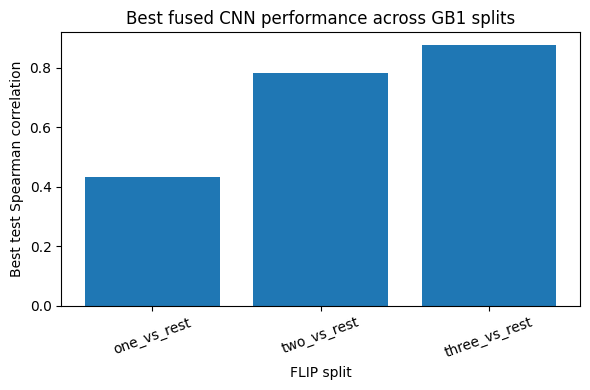

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_df = results_df.set_index("split").loc[SPLIT_COLS]
ax.bar(plot_df.index, plot_df["best_spearman"])
ax.set_ylabel("Best test Spearman correlation")
ax.set_xlabel("FLIP split")
ax.set_title("Best fused CNN performance across GB1 splits")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


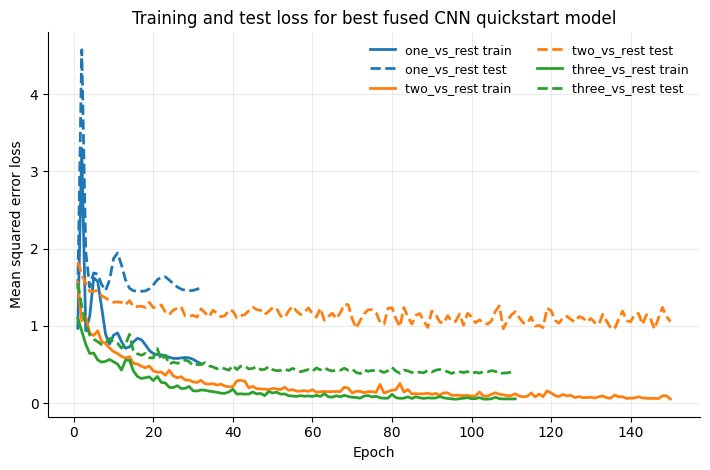

Saved PNG to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_cnn/figures/quickstart_best_cnn_train_test_loss.png
Saved PDF to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_cnn/figures/quickstart_best_cnn_train_test_loss.pdf


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Paper-ready training/test loss curve for quickstart CNN model
# ------------------------------------------------------------

FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

split_display = {
    "one_vs_rest": "one_vs_rest",
    "two_vs_rest": "two_vs_rest",
    "three_vs_rest": "three_vs_rest",
}

# Use matplotlib default color cycle, one color per split
fig, ax = plt.subplots(figsize=(7.2, 4.8))

for split_name in split_order:
    hist_path = OUTPUT_DIR / f"history_{split_name}.csv"
    hist = pd.read_csv(hist_path)

    # Train loss: solid
    ax.plot(
        hist["epoch"],
        hist["train_eval_loss"],
        linestyle="-",
        linewidth=2.0,
        label=f"{split_display[split_name]} train",
    )

    # Test loss: dashed, same color as corresponding train curve
    train_color = ax.lines[-1].get_color()
    ax.plot(
        hist["epoch"],
        hist["test_loss"],
        linestyle="--",
        linewidth=2.0,
        color=train_color,
        label=f"{split_display[split_name]} test",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error loss")
ax.set_title("Training and test loss for best fused CNN quickstart model")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linewidth=0.5, alpha=0.35)

ax.legend(
    frameon=False,
    ncol=2,
    fontsize=9,
    loc="best",
)

plt.tight_layout()

png_path = FIGURE_DIR / "quickstart_best_cnn_train_test_loss.png"
pdf_path = FIGURE_DIR / "quickstart_best_cnn_train_test_loss.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

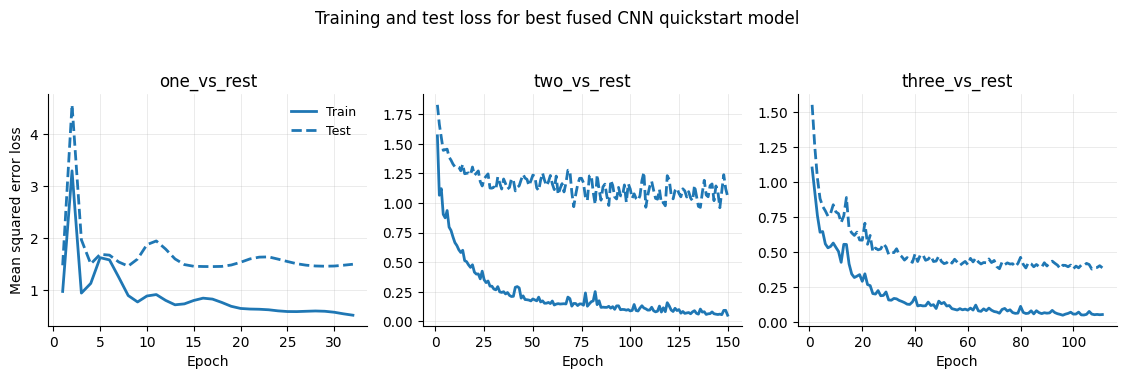

Saved PNG to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_cnn/figures/quickstart_best_cnn_train_test_loss_by_split.png
Saved PDF to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_cnn/figures/quickstart_best_cnn_train_test_loss_by_split.pdf


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Alternative: one panel per split
# Better if loss scales differ substantially across splits
# ------------------------------------------------------------

FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(11.5, 3.6),
    sharex=False,
    sharey=False,
)

for ax, split_name in zip(axes, split_order):
    hist = pd.read_csv(OUTPUT_DIR / f"history_{split_name}.csv")

    ax.plot(
        hist["epoch"],
        hist["train_eval_loss"],
        linestyle="-",
        linewidth=2.0,
        label="Train",
    )

    train_color = ax.lines[-1].get_color()

    ax.plot(
        hist["epoch"],
        hist["test_loss"],
        linestyle="--",
        linewidth=2.0,
        color=train_color,
        label="Test",
    )

    ax.set_title(split_name)
    ax.set_xlabel("Epoch")
    ax.grid(True, linewidth=0.5, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean squared error loss")
axes[0].legend(frameon=False, fontsize=9)

fig.suptitle("Training and test loss for best fused CNN quickstart model", y=1.04)

plt.tight_layout()

png_path = FIGURE_DIR / "quickstart_best_cnn_train_test_loss_by_split.png"
pdf_path = FIGURE_DIR / "quickstart_best_cnn_train_test_loss_by_split.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

## Notes

- This notebook intentionally trains only one final CNN configuration instead of rerunning the full grid search.
- The model selection logic mirrors the exploratory project notebooks by reporting the best test Spearman observed during training. For a more formal benchmark, a separate validation split should be used for early stopping/model selection and the test set should be evaluated once.
- If the full ESM-2 embedding file is too large for GitHub, include `gb1_features_k5.pt` instead and document where the full embedding file can be regenerated or downloaded.


## Best Attention Based Model

In [36]:
attn_dim = 128
attn_num_heads = 8
attn_num_layers = 1
local_pool = "mean"
global_hidden_dims = (128, 64)
fusion_hidden_dims = (64,)
dropout = 0.1
lr = 1e-3
weight_decay = 1e-3

In [37]:
class HybridGB1AttentionLocalModel(nn.Module):
    """
    Original fused attention model from the post-midpoint notebook.

    Fused GB1 model with:
      - global MLP branch over full-sequence mean embedding
      - local TransformerEncoder branch over mutation-window residue embeddings
      - learned positional embeddings for local residue order
      - final LayerNorm after local attention
      - fusion MLP head for regression
    """

    def __init__(
        self,
        embed_dim: int,
        local_len: int,
        global_hidden_dims=(128, 64),
        attn_dim=128,
        attn_num_heads=4,
        attn_num_layers=1,
        attn_ff_dim=256,
        fusion_hidden_dims=(64,),
        dropout: float = 0.1,
        activation: str = "gelu",
        local_pool: str = "max",
    ):
        super().__init__()

        if len(global_hidden_dims) == 0 or len(fusion_hidden_dims) == 0:
            raise ValueError("global_hidden_dims and fusion_hidden_dims must be non-empty.")

        if attn_dim % attn_num_heads != 0:
            raise ValueError(
                f"attn_dim={attn_dim} must be divisible by attn_num_heads={attn_num_heads}."
            )

        if local_pool not in {"max", "mean", "cls"}:
            raise ValueError("local_pool must be one of: 'max', 'mean', 'cls'.")

        self.embed_dim = embed_dim
        self.local_len = local_len
        self.attn_dim = attn_dim
        self.local_pool = local_pool

        self.global_branch = self._make_mlp(
            input_dim=embed_dim,
            hidden_dims=global_hidden_dims,
            dropout=dropout,
            activation=activation,
        )

        # Project ESM embedding dim, e.g. 640, down to attention dim.
        self.local_input_proj = nn.Linear(embed_dim, attn_dim)

        # Learned positional embeddings are important for local residue windows.
        self.pos_embedding = nn.Parameter(torch.zeros(1, local_len, attn_dim))
        nn.init.normal_(self.pos_embedding, mean=0.0, std=0.02)

        if local_pool == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, attn_dim))
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
        else:
            self.cls_token = None

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=attn_dim,
            nhead=attn_num_heads,
            dim_feedforward=attn_ff_dim,
            dropout=dropout,
            activation=activation,
            batch_first=True,
            norm_first=True,
        )

        self.local_attention = nn.TransformerEncoder(
            encoder_layer,
            num_layers=attn_num_layers,
        )

        self.local_norm = nn.LayerNorm(attn_dim)

        fusion_input_dim = global_hidden_dims[-1] + attn_dim

        self.fusion_head = self._make_mlp(
            input_dim=fusion_input_dim,
            hidden_dims=fusion_hidden_dims,
            dropout=dropout,
            activation=activation,
        )

        self.output_layer = nn.Linear(fusion_hidden_dims[-1], 1)

    def _get_activation(self, activation: str):
        activation = activation.lower()
        if activation == "relu":
            return nn.ReLU()
        if activation == "gelu":
            return nn.GELU()
        if activation == "silu":
            return nn.SiLU()
        raise ValueError(f"Unknown activation: {activation}")

    def _make_mlp(self, input_dim, hidden_dims, dropout, activation):
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(self._get_activation(activation))

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        return nn.Sequential(*layers)

    def forward(self, x_seq_mean=None, x_local=None, x_mean=None, x_window=None):
        """
        Accept both naming conventions:
          - x_seq_mean / x_local
          - x_mean / x_window
        """
        if x_seq_mean is None:
            x_seq_mean = x_mean
        if x_local is None:
            x_local = x_window

        if x_seq_mean is None or x_local is None:
            raise ValueError("Provide x_seq_mean/x_local or x_mean/x_window.")

        if x_seq_mean.ndim != 2:
            raise ValueError(
                f"x_seq_mean should have shape (batch, embed_dim), got {tuple(x_seq_mean.shape)}"
            )

        if x_local.ndim != 3:
            raise ValueError(
                f"x_local should have shape (batch, local_len, embed_dim), got {tuple(x_local.shape)}"
            )

        if x_local.shape[1] != self.local_len or x_local.shape[2] != self.embed_dim:
            raise ValueError(
                f"Expected x_local shape (*, {self.local_len}, {self.embed_dim}), "
                f"got {tuple(x_local.shape)}"
            )

        global_repr = self.global_branch(x_seq_mean)

        local_tokens = self.local_input_proj(x_local)
        local_tokens = local_tokens + self.pos_embedding

        if self.local_pool == "cls":
            cls = self.cls_token.expand(local_tokens.shape[0], -1, -1)
            local_tokens = torch.cat([cls, local_tokens], dim=1)

        local_tokens = self.local_attention(local_tokens)
        local_tokens = self.local_norm(local_tokens)

        if self.local_pool == "max":
            local_repr = local_tokens.max(dim=1).values
        elif self.local_pool == "mean":
            local_repr = local_tokens.mean(dim=1)
        elif self.local_pool == "cls":
            local_repr = local_tokens[:, 0, :]
        else:
            raise ValueError(f"Unknown local_pool: {self.local_pool}")

        fused = torch.cat([global_repr, local_repr], dim=-1)
        fused = self.fusion_head(fused)
        out = self.output_layer(fused).squeeze(-1)

        return out

In [38]:
BEST_ATTENTION_CONFIG = {
    "seed": 42,
    "global_hidden_dims": (128, 64),
    "attn_dim": 128,
    "attn_num_heads": 8,
    "attn_num_layers": 1,
    "attn_ff_dim": 256,
    "fusion_hidden_dims": (64,),
    "dropout": 0.1,
    "activation": "gelu",
    "local_pool": "mean",
    "lr": 1e-3,
    "weight_decay": 1e-3,
    "batch_size": 128,
    "test_batch_size": 512,
    "max_epochs": 150,
    "patience": 25,
}


def train_one_hybrid_attention_split(split_name, config=BEST_ATTENTION_CONFIG, verbose=True):
    set_seed(config.get("seed", 42))

    train_loader, test_loader = make_hybrid_loaders(
        split_tensors_hybrid,
        split_name=split_name,
        batch_size=config["batch_size"],
        test_batch_size=config.get("test_batch_size", 512),
    )

    embed_dim = split_tensors_hybrid[split_name]["X_mean_train"].shape[-1]
    local_len = split_tensors_hybrid[split_name]["X_window_train"].shape[1]

    model = HybridGB1AttentionLocalModel(
        embed_dim=embed_dim,
        local_len=local_len,
        global_hidden_dims=config["global_hidden_dims"],
        attn_dim=config["attn_dim"],
        attn_num_heads=config["attn_num_heads"],
        attn_num_layers=config["attn_num_layers"],
        attn_ff_dim=config["attn_ff_dim"],
        fusion_hidden_dims=config["fusion_hidden_dims"],
        dropout=config["dropout"],
        activation=config.get("activation", "gelu"),
        local_pool=config.get("local_pool", "mean"),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    loss_fn = nn.MSELoss()

    history = []
    best_spearman = -np.inf
    best_epoch = None
    best_state_dict = None
    best_summary = None
    epochs_without_improvement = 0

    for epoch in range(1, config.get("max_epochs", 150) + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0

        for batch in train_loader:
            x_mean = batch["mean"].to(DEVICE)
            x_window = batch["window"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x_mean=x_mean, x_window=x_window)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * y.numel()
            train_n += y.numel()

        train_eval, _, _ = evaluate_hybrid_model(model, train_loader, device=DEVICE)
        test_eval, _, _ = evaluate_hybrid_model(model, test_loader, device=DEVICE)

        row = {
            "epoch": epoch,
            "train_loss": train_loss_sum / max(train_n, 1),
            "train_eval_loss": train_eval["loss"],
            "test_loss": test_eval["loss"],
            "train_spearman": train_eval["spearman"],
            "test_spearman": test_eval["spearman"],
            "train_mae": train_eval["mae"],
            "test_mae": test_eval["mae"],
        }
        history.append(row)

        if verbose and (epoch == 1 or epoch % 10 == 0):
            print(
                f"{split_name} | epoch {epoch:03d} | "
                f"train loss {row['train_eval_loss']:.4f} | "
                f"test loss {row['test_loss']:.4f} | "
                f"test Spearman {row['test_spearman']:.4f}"
            )

        # Mirrors the exploratory notebooks: best test Spearman is tracked.
        # For formal benchmarking, replace with validation-based selection.
        if test_eval["spearman"] > best_spearman:
            best_spearman = test_eval["spearman"]
            best_epoch = epoch
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            best_summary = {
                "model": "Fused Attention",
                "split": split_name,
                "n_train": int(split_tensors_hybrid[split_name]["y_train"].numel()),
                "n_test": int(split_tensors_hybrid[split_name]["y_test"].numel()),
                "best_epoch": int(best_epoch),
                "best_spearman": float(test_eval["spearman"]),
                "best_train_loss": float(train_eval["loss"]),
                "best_test_loss": float(test_eval["loss"]),
                "best_train_mae": float(train_eval["mae"]),
                "best_test_mae": float(test_eval["mae"]),
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config.get("patience", 25):
            if verbose:
                print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

    history_df = pd.DataFrame(history)

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    _, y_test_np, pred_test_np = evaluate_hybrid_model(
        model,
        test_loader,
        device=DEVICE,
    )

    return {
        "summary": best_summary,
        "history": history_df,
        "model": model,
        "config": dict(config),
        "y_test": y_test_np,
        "pred_test": pred_test_np,
    }

In [39]:
attention_results = []
attention_histories = {}
attention_predictions = {}

for split_name in SPLIT_COLS:
    print("=" * 100)
    print(f"Training best fused attention model on {split_name}")
    print("=" * 100)

    result = train_one_hybrid_attention_split(
        split_name,
        config=BEST_ATTENTION_CONFIG,
        verbose=True,
    )

    attention_results.append(result["summary"])
    attention_histories[split_name] = result["history"]
    attention_predictions[split_name] = {
        "y_test": result["y_test"],
        "pred_test": result["pred_test"],
    }

attention_results_df = pd.DataFrame(attention_results)
display(attention_results_df)

Training best fused attention model on one_vs_rest


/tmp/ipykernel_4016/3412402924.py:75: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.local_attention = nn.TransformerEncoder(


one_vs_rest | epoch 001 | train loss 1.0191 | test loss 1.4828 | test Spearman 0.4709
one_vs_rest | epoch 010 | train loss 0.7882 | test loss 1.7316 | test Spearman 0.1711
one_vs_rest | epoch 020 | train loss 0.7601 | test loss 1.7142 | test Spearman 0.2161
Early stopping at epoch 26; best epoch was 1.
Training best fused attention model on two_vs_rest
two_vs_rest | epoch 001 | train loss 1.0979 | test loss 1.8251 | test Spearman 0.3882
two_vs_rest | epoch 010 | train loss 0.8005 | test loss 1.3941 | test Spearman 0.3924
two_vs_rest | epoch 020 | train loss 0.6056 | test loss 1.3502 | test Spearman 0.4622
two_vs_rest | epoch 030 | train loss 0.3573 | test loss 1.2065 | test Spearman 0.5623
two_vs_rest | epoch 040 | train loss 0.3332 | test loss 1.1920 | test Spearman 0.6063
two_vs_rest | epoch 050 | train loss 0.2772 | test loss 1.1237 | test Spearman 0.6295
two_vs_rest | epoch 060 | train loss 0.2181 | test loss 0.9979 | test Spearman 0.6875
two_vs_rest | epoch 070 | train loss 0.1966

,model,split,n_train,n_test,best_epoch,best_spearman,best_train_loss,best_test_loss,best_train_mae,best_test_mae
0,Fused Attention,one_vs_rest,28,8705,1,0.470900,1.019120,1.482761,0.682225,0.943227
1,Fused Attention,two_vs_rest,424,8309,75,0.702754,0.123317,1.016865,0.252746,0.689421
2,Fused Attention,three_vs_rest,2990,5743,39,0.870216,0.145395,0.551227,0.272292,0.476233


In [40]:
ATTENTION_OUTPUT_DIR = DATA_DIR / "outputs" / "quickstart_best_attention"
ATTENTION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

attention_results_df.to_csv(
    ATTENTION_OUTPUT_DIR / "best_attention_split_results.csv",
    index=False,
)

for split_name, hist in attention_histories.items():
    hist.to_csv(ATTENTION_OUTPUT_DIR / f"history_{split_name}.csv", index=False)

    pred_df = pd.DataFrame(attention_predictions[split_name])
    pred_df.to_csv(
        ATTENTION_OUTPUT_DIR / f"predictions_{split_name}.csv",
        index=False,
    )

print("Saved attention outputs to:", ATTENTION_OUTPUT_DIR.resolve())

Saved attention outputs to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_attention


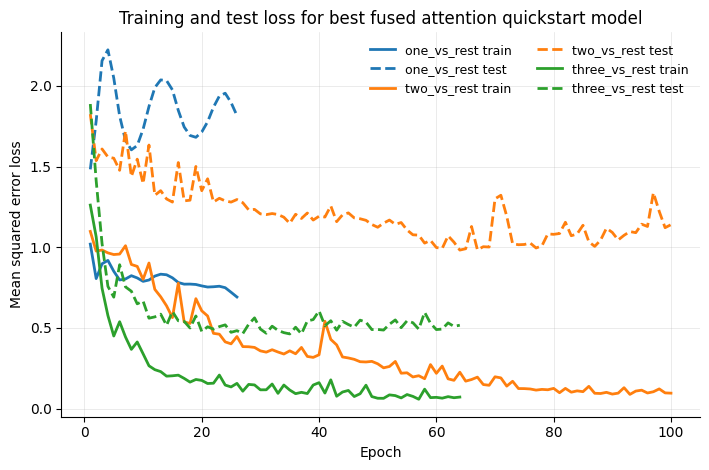

Saved PNG to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_attention/figures/quickstart_best_attention_train_test_loss.png
Saved PDF to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_best_attention/figures/quickstart_best_attention_train_test_loss.pdf


In [41]:
FIGURE_DIR = ATTENTION_OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

fig, ax = plt.subplots(figsize=(7.2, 4.8))

for split_name in split_order:
    hist = pd.read_csv(ATTENTION_OUTPUT_DIR / f"history_{split_name}.csv")

    ax.plot(
        hist["epoch"],
        hist["train_eval_loss"],
        linestyle="-",
        linewidth=2.0,
        label=f"{split_name} train",
    )

    train_color = ax.lines[-1].get_color()

    ax.plot(
        hist["epoch"],
        hist["test_loss"],
        linestyle="--",
        linewidth=2.0,
        color=train_color,
        label=f"{split_name} test",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean squared error loss")
ax.set_title("Training and test loss for best fused attention quickstart model")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linewidth=0.5, alpha=0.35)

ax.legend(
    frameon=False,
    ncol=2,
    fontsize=9,
    loc="best",
)

plt.tight_layout()

png_path = FIGURE_DIR / "quickstart_best_attention_train_test_loss.png"
pdf_path = FIGURE_DIR / "quickstart_best_attention_train_test_loss.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

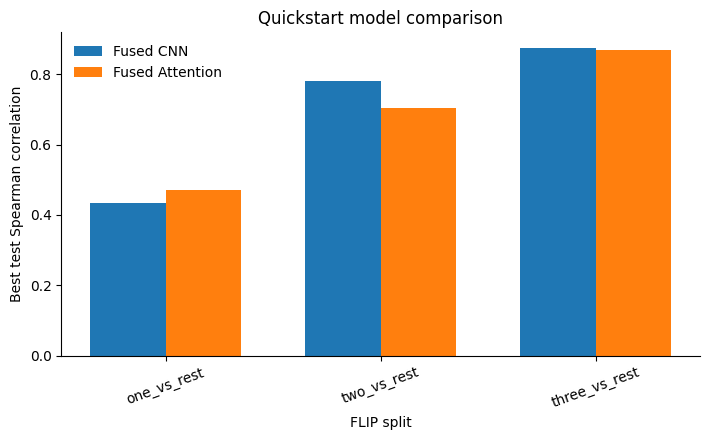

Saved PNG to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_cnn_vs_attention_spearman.png
Saved PDF to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/quickstart_cnn_vs_attention_spearman.pdf


In [42]:
cnn_results_path = DATA_DIR / "outputs" / "quickstart_best_cnn" / "best_cnn_split_results.csv"
attention_results_path = ATTENTION_OUTPUT_DIR / "best_attention_split_results.csv"

cnn_df = pd.read_csv(cnn_results_path)
attn_df = pd.read_csv(attention_results_path)

compare_df = pd.concat([cnn_df, attn_df], ignore_index=True)

fig, ax = plt.subplots(figsize=(7.2, 4.5))

x = np.arange(len(SPLIT_COLS))
width = 0.35

cnn_vals = (
    compare_df[compare_df["model"] == "Fused CNN"]
    .set_index("split")
    .loc[SPLIT_COLS, "best_spearman"]
)

attn_vals = (
    compare_df[compare_df["model"] == "Fused Attention"]
    .set_index("split")
    .loc[SPLIT_COLS, "best_spearman"]
)

ax.bar(x - width / 2, cnn_vals.values, width, label="Fused CNN")
ax.bar(x + width / 2, attn_vals.values, width, label="Fused Attention")

ax.set_xticks(x)
ax.set_xticklabels(SPLIT_COLS, rotation=20)
ax.set_ylabel("Best test Spearman correlation")
ax.set_xlabel("FLIP split")
ax.set_title("Quickstart model comparison")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()

comparison_png = DATA_DIR / "outputs" / "quickstart_cnn_vs_attention_spearman.png"
comparison_pdf = DATA_DIR / "outputs" / "quickstart_cnn_vs_attention_spearman.pdf"

plt.savefig(comparison_png, dpi=300, bbox_inches="tight")
plt.savefig(comparison_pdf, bbox_inches="tight")

plt.show()

print(f"Saved PNG to: {comparison_png}")
print(f"Saved PDF to: {comparison_pdf}")

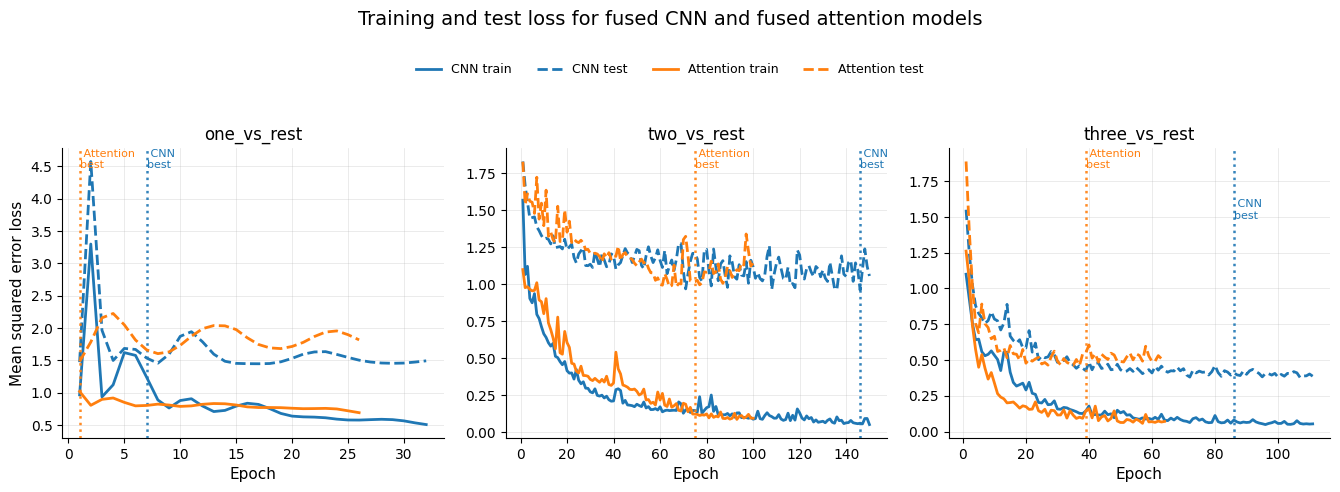

Saved PNG to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/figures/quickstart_cnn_attention_train_test_loss_by_split.png
Saved PDF to: /content/drive/MyDrive/CBMF 4761 /FLIP/GB1/outputs/figures/quickstart_cnn_attention_train_test_loss_by_split.pdf


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 3-panel paper-ready loss plot:
# Each panel = split
# Color = model architecture
# Line style = train vs test
# Vertical line = best epoch for that model/split
# ------------------------------------------------------------

CNN_OUTPUT_DIR = DATA_DIR / "outputs" / "quickstart_best_cnn"
ATTN_OUTPUT_DIR = DATA_DIR / "outputs" / "quickstart_best_attention"

FIGURE_DIR = DATA_DIR / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

split_order = ["one_vs_rest", "two_vs_rest", "three_vs_rest"]

split_display = {
    "one_vs_rest": "one_vs_rest",
    "two_vs_rest": "two_vs_rest",
    "three_vs_rest": "three_vs_rest",
}

model_info = {
    "CNN": {
        "history_dir": CNN_OUTPUT_DIR,
        "results_path": CNN_OUTPUT_DIR / "best_cnn_split_results.csv",
    },
    "Attention": {
        "history_dir": ATTN_OUTPUT_DIR,
        "results_path": ATTN_OUTPUT_DIR / "best_attention_split_results.csv",
    },
}

# Matplotlib default colors; avoids hard-coding colors but keeps each model consistent
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {
    "CNN": default_colors[0],
    "Attention": default_colors[1],
}

# Load summary files, if present, to get best_epoch
summary_tables = {}
for model_name, info in model_info.items():
    if info["results_path"].exists():
        summary_tables[model_name] = pd.read_csv(info["results_path"])
    else:
        summary_tables[model_name] = None
        print(f"Warning: could not find {info['results_path']}. "
              "Best epoch will be inferred from max test_spearman in history.")

def get_best_epoch(model_name, split_name, hist):
    """
    Prefer best_epoch from saved summary CSV.
    If unavailable, infer from the epoch with max test_spearman.
    """
    summary_df = summary_tables.get(model_name)

    if summary_df is not None and {"split", "best_epoch"}.issubset(summary_df.columns):
        match = summary_df.loc[summary_df["split"] == split_name, "best_epoch"]
        if len(match) > 0 and pd.notna(match.iloc[0]):
            return int(match.iloc[0])

    if "test_spearman" in hist.columns:
        return int(hist.loc[hist["test_spearman"].idxmax(), "epoch"])

    # Last fallback: epoch with minimum test loss
    return int(hist.loc[hist["test_loss"].idxmin(), "epoch"])


fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.2),
    sharex=False,
    sharey=False,
)

for ax, split_name in zip(axes, split_order):

    for model_name, info in model_info.items():
        hist_path = info["history_dir"] / f"history_{split_name}.csv"

        if not hist_path.exists():
            print(f"Skipping missing file: {hist_path}")
            continue

        hist = pd.read_csv(hist_path)

        color = model_colors[model_name]
        best_epoch = get_best_epoch(model_name, split_name, hist)

        # Train loss: solid
        ax.plot(
            hist["epoch"],
            hist["train_eval_loss"],
            linestyle="-",
            linewidth=2.0,
            color=color,
            label=f"{model_name} train",
        )

        # Test loss: dashed
        ax.plot(
            hist["epoch"],
            hist["test_loss"],
            linestyle="--",
            linewidth=2.0,
            color=color,
            label=f"{model_name} test",
        )

        # Best epoch: vertical dotted line, same model color
        ax.axvline(
            best_epoch,
            linestyle=":",
            linewidth=1.8,
            color=color,
            alpha=0.9,
        )

        # Optional small label near top of panel
        y_min, y_max = ax.get_ylim()
        ax.text(
            best_epoch,
            y_max,
            f" {model_name}\nbest",
            color=color,
            fontsize=8,
            va="top",
            ha="left",
            rotation=0,
        )

    ax.set_title(split_display[split_name], fontsize=12)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.grid(True, linewidth=0.5, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean squared error loss", fontsize=11)

# One shared legend for all panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),
    fontsize=9,
)

fig.suptitle(
    "Training and test loss for fused CNN and fused attention models",
    fontsize=14,
    y=1.16,
)

plt.tight_layout()

png_path = FIGURE_DIR / "quickstart_cnn_attention_train_test_loss_by_split.png"
pdf_path = FIGURE_DIR / "quickstart_cnn_attention_train_test_loss_by_split.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")